# PCB Defect Detection Training

This notebook trains a one-class defect detector ("defect" vs background) on the COCO annotations, then fine-tunes it using the SEM + lithography simulation pipeline from `lithography_simulation.ipynb`.

Pipeline stages:
- Stage 1: Train Faster R-CNN (one-class) on original PCB images.
- Stage 2: Fine-tune the same model with lithography-based augmentation, keeping bounding boxes unchanged.


In [1]:
# Imports and configuration
import os
import json
import random
from collections import defaultdict

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Force CUDA device only
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU is required but was not found. Please enable a GPU runtime.")

DEVICE = torch.device("cuda")
print(f"Using device: {DEVICE}")

DATA_ROOT = "."  # this notebook is inside PCB Defect Detection.v4i.coco
TRAIN_JSON = os.path.join(DATA_ROOT, "train", "_annotations.coco.json")
VALID_JSON = os.path.join(DATA_ROOT, "valid", "_annotations.coco.json")
TEST_JSON = os.path.join(DATA_ROOT, "test", "_annotations.coco.json")

USE_ONE_CLASS = True  # all defects -> single "defect" class


Using device: cuda


c:\Users\Shlomi\Desktop\lola lithography home assignment save before synthetic data\PCB Defect Detection.v4i.coco\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# COCO loading utilities

def load_coco_annotations(ann_path):
    with open(ann_path, "r") as f:
        coco = json.load(f)
    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    categories = coco.get("categories", [])

    image_id_to_info = {img["id"]: img for img in images}
    image_id_to_anns = defaultdict(list)
    for ann in annotations:
        image_id_to_anns[ann["image_id"]].append(ann)

    categories_by_id = {c["id"]: c for c in categories}
    return image_id_to_info, image_id_to_anns, categories_by_id


class PCBDefectsCocoDataset(Dataset):
    def __init__(self, root_dir, ann_path, transforms=None, one_class=True):
        self.root_dir = root_dir
        self.ann_path = ann_path
        self.transforms = transforms
        self.one_class = one_class

        self.image_id_to_info, self.image_id_to_anns, self.categories = load_coco_annotations(ann_path)
        # Stable list of image infos
        self.images = list(self.image_id_to_info.values())

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        image_id = img_info["id"]
        file_name = img_info["file_name"]

        # Images live in the same folder as the annotations JSON
        images_dir = os.path.dirname(self.ann_path)
        img_path = os.path.join(images_dir, file_name)

        img = Image.open(img_path).convert("RGB")

        anns = self.image_id_to_anns.get(image_id, [])
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h
            boxes.append([x1, y1, x2, y2])

            if self.one_class:
                labels.append(1)  # single "defect" class
            else:
                # shift category id by +1 to keep 0 as background
                labels.append(int(ann["category_id"]) + 1)

            areas.append(ann.get("area", w * h))
            iscrowd.append(ann.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


# Simple transforms (no resize yet)
class ToTensorTransform:
    def __call__(self, img, target):
        img = F.to_tensor(img)
        return img, target


def get_train_transforms_basic():
    return ToTensorTransform()


def get_valid_transforms():
    return ToTensorTransform()


In [3]:
# Model definition and training utilities

def create_defect_detector(one_class=True):
    if one_class:
        num_classes = 2  # background + defect
    else:
        num_classes = 8  # background + 7 defect categories

    # Load a pre-trained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

    # Replace the box predictor head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(data_loader, desc=f"Train Epoch {epoch}")

    for i, (images, targets) in enumerate(progress_bar, start=1):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        running_loss += loss_value
        avg_loss = running_loss / i
        progress_bar.set_postfix({"loss": f"{avg_loss:.4f}"})
    
    return avg_loss  # Return average loss for plotting


def save_checkpoint(path, epoch, model, optimizer, scheduler, loss_history):
    """Save checkpoint with full training state."""
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "loss_history": loss_history,
    }
    torch.save(checkpoint, path)
    print(f"  [Checkpoint] Saved at epoch {epoch} to {path}")


def load_checkpoint(path, model, optimizer, scheduler, device):
    """Load checkpoint and return start epoch and loss history."""
    if os.path.isfile(path):
        checkpoint = torch.load(path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        loss_history = checkpoint.get("loss_history", [])
        print(f"  [Checkpoint] Resuming from epoch {start_epoch} (loaded from {path})")
        return start_epoch, loss_history
    return 1, []  # Start from epoch 1 if no checkpoint


def plot_training_loss(loss_history, title, stage_name):
    """Plot training loss curve."""
    plt.figure(figsize=(10, 6))
    epochs = range(1, len(loss_history) + 1)
    plt.plot(epochs, loss_history, 'b-o', linewidth=2, markersize=6)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Average Loss', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(epochs)
    plt.tight_layout()
    plt.savefig(f"models/{stage_name}_loss_curve.png", dpi=150)
    plt.show()
    print(f"  Loss curve saved to models/{stage_name}_loss_curve.png")


@torch.no_grad()
def evaluate_one_epoch(model, data_loader, device, score_thresh=0.5, iou_thresh=0.5):
    from torchvision.ops import box_iou

    model.eval()
    total_tp, total_fp, total_fn = 0, 0, 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"].to(device)
            if gt_boxes.numel() == 0:
                continue

            scores = output["scores"].to(device)
            pred_boxes = output["boxes"][scores >= score_thresh].to(device)

            if pred_boxes.numel() == 0:
                total_fn += gt_boxes.size(0)
                continue

            ious = box_iou(pred_boxes, gt_boxes)
            max_iou, _ = ious.max(dim=1)

            tp = (max_iou >= iou_thresh).sum().item()
            fp = (max_iou < iou_thresh).sum().item()
            fn = max(gt_boxes.size(0) - tp, 0)

            total_tp += tp
            total_fp += fp
            total_fn += fn

    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)

    print(f"Validation | TP: {total_tp} FP: {total_fp} FN: {total_fn} | Precision: {precision:.3f} Recall: {recall:.3f}")

    return {"tp": total_tp, "fp": total_fp, "fn": total_fn, "precision": precision, "recall": recall}


Training set: 1053 images
Validation set: 301 images

Visualizing training samples with ground-truth bounding boxes...


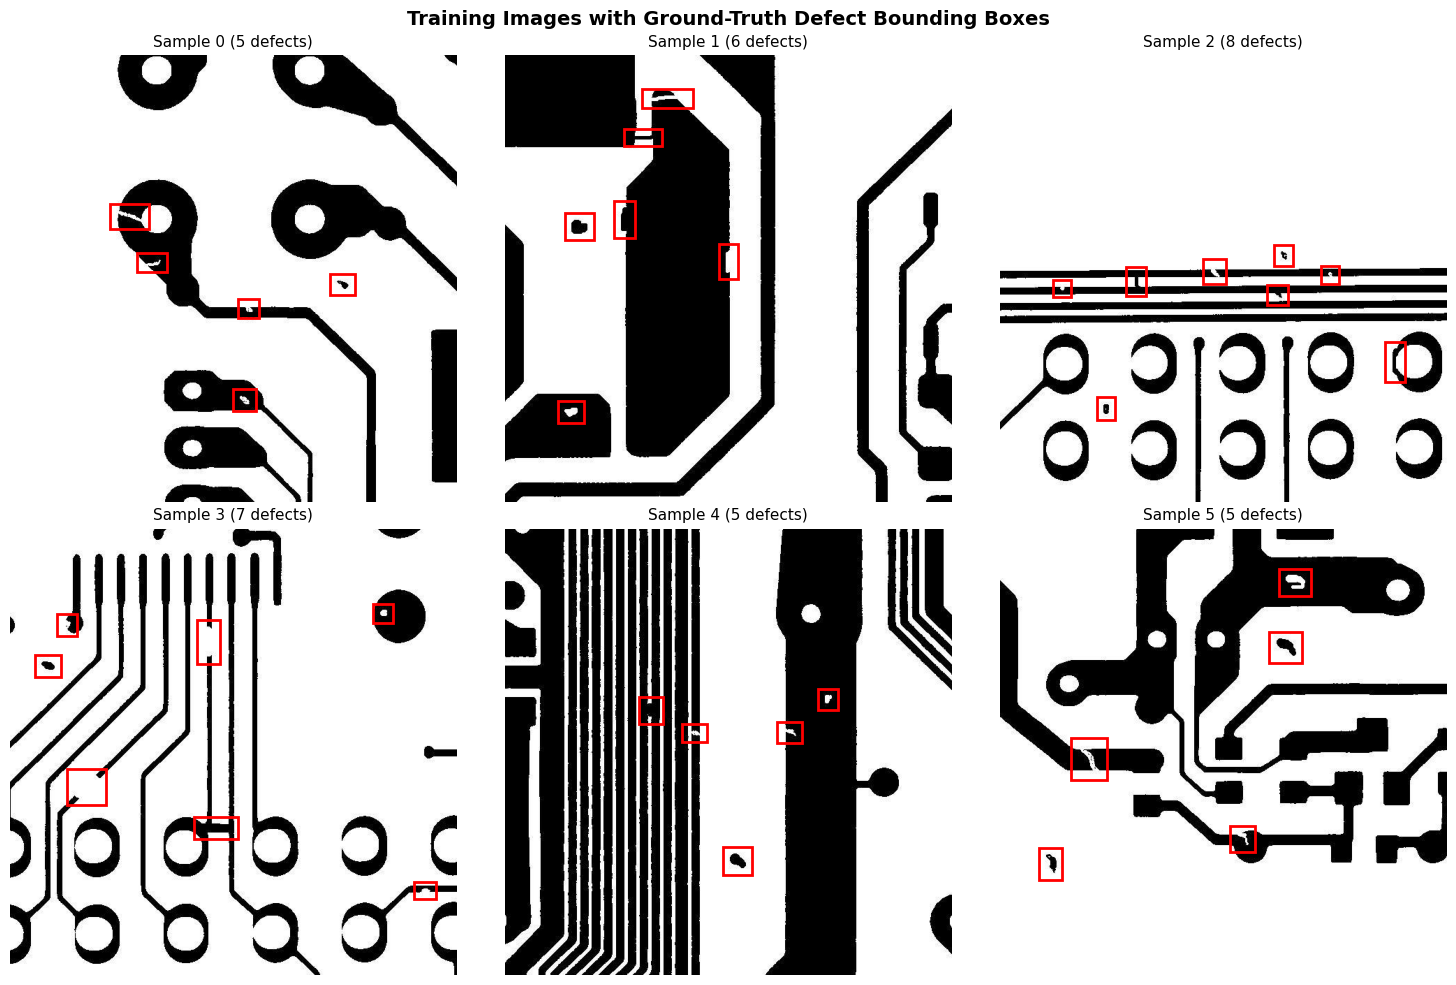

Visualization complete.

Creating Faster R-CNN model...
Model moved to cuda
Optimizer: SGD with lr=0.005, momentum=0.9
Model moved to cuda
Optimizer: SGD with lr=0.005, momentum=0.9
  [Checkpoint] Resuming from epoch 21 (loaded from models\defect_detector_stage1_checkpoint.pth)

[Stage 1] Training from epoch 21 to 40 (20 epochs this run)...
  Total epochs after this run: 40

===== Epoch 21/40 (Stage 1: Original images) =====
  [Checkpoint] Resuming from epoch 21 (loaded from models\defect_detector_stage1_checkpoint.pth)

[Stage 1] Training from epoch 21 to 40 (20 epochs this run)...
  Total epochs after this run: 40

===== Epoch 21/40 (Stage 1: Original images) =====


Train Epoch 21:   3%|▎         | 8/264 [00:05<02:51,  1.49it/s, loss=0.1193]



KeyboardInterrupt: 

In [4]:
# Stage 1: Train on original PCB images (no lithography)

# Datasets and dataloaders
train_dataset = PCBDefectsCocoDataset(
    root_dir=DATA_ROOT,
    ann_path=TRAIN_JSON,
    transforms=get_train_transforms_basic(),
    one_class=USE_ONE_CLASS,
)

valid_dataset = PCBDefectsCocoDataset(
    root_dir=DATA_ROOT,
    ann_path=VALID_JSON,
    transforms=get_valid_transforms(),
    one_class=USE_ONE_CLASS,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,  # Windows compatibility: 0 avoids multiprocessing hang
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,  # Windows compatibility: 0 avoids multiprocessing hang
    collate_fn=collate_fn,
)

print(f"Training set: {len(train_dataset)} images")
print(f"Validation set: {len(valid_dataset)} images")

# Visualize a few training samples with bounding boxes
print("\nVisualizing training samples with ground-truth bounding boxes...")
num_samples_to_show = 6
rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i in range(num_samples_to_show):
    img, target = train_dataset[i]

    # img is tensor [C,H,W]; convert to HWC for plotting
    img_np = img.permute(1, 2, 0).numpy()

    ax = axes[i]
    ax.imshow(img_np)
    
    boxes = target["boxes"].numpy()
    num_defects = len(boxes)
    ax.set_title(f"Sample {i} ({num_defects} defect{'s' if num_defects != 1 else ''})", fontsize=11)
    ax.axis("off")

    for (x1, y1, x2, y2) in boxes:
        w = x2 - x1
        h = y2 - y1
        rect = plt.Rectangle((x1, y1), w, h, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)

plt.suptitle("Training Images with Ground-Truth Defect Bounding Boxes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Visualization complete.\n")

# Create model and optimizer
print("Creating Faster R-CNN model...")
model = create_defect_detector(one_class=USE_ONE_CLASS)
model.to(DEVICE)
print(f"Model moved to {DEVICE}")

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
print(f"Optimizer: SGD with lr=0.005, momentum=0.9")

# CONFIGURATION: Number of epochs to train each time you run this cell
epochs_per_run = 20  # Change this to train more/fewer epochs per run
checkpoint_frequency = 5
os.makedirs("models", exist_ok=True)
baseline_checkpoint_path = os.path.join("models", "defect_detector_stage1_checkpoint.pth")
baseline_path = os.path.join("models", "defect_detector_stage1_baseline.pth")

# Try to resume from checkpoint
start_epoch, stage1_losses = load_checkpoint(baseline_checkpoint_path, model, optimizer, scheduler, DEVICE)

# Calculate end epoch: start from where we left off and train for epochs_per_run more
end_epoch = start_epoch + epochs_per_run - 1
print(f"\n[Stage 1] Training from epoch {start_epoch} to {end_epoch} ({epochs_per_run} epochs this run)...")
print(f"  Total epochs after this run: {end_epoch}")

for epoch in range(start_epoch, end_epoch + 1):
    print(f"\n===== Epoch {epoch}/{end_epoch} (Stage 1: Original images) =====")
    epoch_loss = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch)
    stage1_losses.append(epoch_loss)
    metrics = evaluate_one_epoch(model, valid_loader, DEVICE)
    scheduler.step()
    
    # Save checkpoint every 5 epochs
    if epoch % checkpoint_frequency == 0:
        save_checkpoint(baseline_checkpoint_path, epoch, model, optimizer, scheduler, stage1_losses)

# Save final baseline model (just weights for inference)
torch.save(model.state_dict(), baseline_path)
print(f"\nSaved Stage 1 baseline model to: {baseline_path}")

# Plot Stage 1 training loss
plot_training_loss(stage1_losses, f"Stage 1: Baseline Training Loss ({len(stage1_losses)} total epochs)", "stage1_baseline")

In [ ]:
# Visualize a few training images and their bounding boxes

num_samples_to_show = 4
rows = 2
cols = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 12))
axes = axes.flatten()

for i in range(num_samples_to_show):
    img, target = train_dataset[i]

    # img is tensor [C,H,W]; convert to HWC for plotting
    img_np = img.permute(1, 2, 0).numpy()

    ax = axes[i]
    ax.imshow(img_np)
    ax.set_title(f"Train sample {i}")
    ax.axis("off")

    boxes = target["boxes"].numpy()
    for (x1, y1, x2, y2) in boxes:
        w = x2 - x1
        h = y2 - y1
        rect = plt.Rectangle((x1, y1), w, h, fill=False, color="red", linewidth=1.5)
        ax.add_patch(rect)

plt.tight_layout()
plt.show()


In [5]:
# Lithography utilities (copied from lithography_simulation.ipynb)

from scipy import ndimage
from scipy.signal import fftconvolve
from scipy.special import j1
import time


def inject_bright_particles(img_array, existing_boxes=None, num_particles=None):
    """Inject bright particles with moderate soft edges into image.
    
    Args:
        img_array: numpy array (H, W) with values 0-255
        existing_boxes: list of [x1, y1, x2, y2] boxes to avoid overlap
        num_particles: number of particles to add (default: random 0-2)
    
    Returns:
        img_array: modified image with particles
        new_boxes: list of [x1, y1, x2, y2] bounding boxes for particles
    """
    h, w = img_array.shape[:2]
    img_out = img_array.copy().astype(float)
    
    if num_particles is None:
        num_particles = random.randint(0, 2)
    
    new_boxes = []
    
    for _ in range(num_particles):
        # Large particle: 10-50% of image size
        min_diameter = int(min(h, w) * 0.10)
        max_diameter = int(min(h, w) * 0.50)
        diameter = random.randint(min_diameter, max_diameter)
        radius = diameter // 2
        
        # Random center position (keep particle fully inside image)
        margin = radius + 5
        cx = random.randint(margin, w - margin)
        cy = random.randint(margin, h - margin)
        
        # Toned down intensity range: 200-230
        peak_intensity = random.randint(200, 230)
        
        y_coords, x_coords = np.ogrid[:h, :w]
        dist_sq = (x_coords - cx) ** 2 + (y_coords - cy) ** 2
        dist = np.sqrt(dist_sq)
        
        # Moderate soft edge (~30% of radius for softer transition)
        edge_width = max(5, radius * 0.3)
        particle = np.zeros_like(dist)
        
        # Inside the core: full intensity
        particle[dist <= radius - edge_width] = 1.0
        
        # Gradual soft edge transition (smoother falloff)
        edge_mask = (dist > radius - edge_width) & (dist <= radius + edge_width * 0.5)
        edge_dist = dist[edge_mask] - (radius - edge_width)
        edge_total = edge_width * 1.5
        particle[edge_mask] = 1.0 - (edge_dist / edge_total) ** 1.5  # Smoother curve
        
        particle = np.clip(particle, 0, 1) * peak_intensity
        img_out = np.maximum(img_out, particle)
        
        # Bounding box based on the circle radius
        x1 = max(0, int(cx - radius))
        y1 = max(0, int(cy - radius))
        x2 = min(w - 1, int(cx + radius))
        y2 = min(h - 1, int(cy + radius))
        new_boxes.append([x1, y1, x2, y2])
    
    img_out = np.clip(img_out, 0, 255).astype(np.uint8)
    return img_out, new_boxes


def convert_to_sem_style(img):
    """Apply SEM-style conversion used in lithography_simulation.ipynb.

    1. Convert to grayscale.
    2. Remap colors: black -> gray (124,124,124), white -> dark gray (57,57,57).
    3. Apply slight blur, noise, grain, and vignetting.
    """
    img_gray = img.convert("L")
    img_array = np.array(img_gray).astype(float) / 255.0

    # Linear color remap: 0 -> 124/255, 1 -> 57/255
    img_remapped = img_array * (-67 / 255.0) + (124 / 255.0)

    # Slight Gaussian blur
    img_blur = ndimage.gaussian_filter(img_remapped, sigma=0.05)

    # Noise
    noise = np.random.normal(0, 0.015, img_blur.shape)
    img_noisy = img_blur + noise
    img_noisy = np.clip(img_noisy, 0.0, 1.0)

    # Fine grain texture
    grain_size = 2
    grain = np.random.normal(0, 0.01, (img_noisy.shape[0] // grain_size, img_noisy.shape[1] // grain_size))
    grain_upscaled = ndimage.zoom(grain, grain_size, order=1)
    if grain_upscaled.shape != img_noisy.shape:
        grain_upscaled = grain_upscaled[: img_noisy.shape[0], : img_noisy.shape[1]]
    img_grain = img_noisy + grain_upscaled
    img_grain = np.clip(img_grain, 0.0, 1.0)

    # Slight vignetting
    rows, cols = img_grain.shape
    y, x = np.ogrid[:rows, :cols]
    center_y, center_x = rows / 2, cols / 2
    max_dist = np.sqrt(center_y ** 2 + center_x ** 2)
    dist_from_center = np.sqrt((y - center_y) ** 2 + (x - center_x) ** 2)
    vignette = 1 - 0.06 * (dist_from_center / max_dist) ** 2
    img_sem = img_grain * vignette

    img_sem = np.clip(img_sem, 0.0, 1.0)
    img_sem = (img_sem * 255).astype(np.uint8)
    return Image.fromarray(img_sem)


def simulate_lithography(img, wavelength=193, na=1.2, defocus=0, dose=1.0, verbose=False):
    """Physics-inspired optical lithography simulation (same as notebook version)."""
    start_time = time.time()

    img_gray = img.convert("L")
    mask = np.array(img_gray).astype(float) / 255.0

    # Mask pattern (no inversion)
    mask_pattern = mask

    # Optical PSF
    resolution_limit = wavelength / (2 * na)
    pixel_scale = 10  # nm per pixel
    psf_radius_pixels = int(resolution_limit / pixel_scale)
    psf_radius_pixels = max(5, min(psf_radius_pixels, 50))
    psf_size = psf_radius_pixels * 2 + 1

    y, x = np.ogrid[-psf_radius_pixels : psf_radius_pixels + 1, -psf_radius_pixels : psf_radius_pixels + 1]
    r = np.sqrt(x ** 2 + y ** 2)

    v = 2 * np.pi * na * r * pixel_scale / wavelength
    v[v == 0] = 1e-10
    airy = (2 * j1(v) / v) ** 2
    airy = airy / airy.sum()

    if defocus != 0:
        defocus_phase = np.pi * na ** 2 * (r * pixel_scale) ** 2 * defocus / wavelength ** 2
        defocus_kernel = np.cos(defocus_phase)
        airy = airy * (1 + 0.5 * defocus_kernel)
        airy = airy / airy.sum()

    # Convolution
    aerial_image = fftconvolve(mask_pattern, airy, mode="same")
    aerial_image = np.clip(aerial_image, 0.0, 1.0)

    # Exposure and resist
    exposure = aerial_image * dose
    resist_contrast = 5.0
    threshold = 0.5
    developed_resist = 1 / (1 + np.exp(-resist_contrast * (exposure - threshold)))

    # Process variations
    ler_noise = np.random.normal(0, 0.02, developed_resist.shape)
    developed_resist = np.clip(developed_resist + ler_noise, 0, 1)

    defect_probability = 0.001
    defect_mask = np.random.random(developed_resist.shape) < defect_probability
    if defect_mask.any():
        developed_resist[defect_mask] = np.random.uniform(0.3, 0.7, np.sum(defect_mask))

    final_pattern = (developed_resist * 255).astype(np.uint8)

    if verbose:
        print(f"Lithography simulation time: {time.time() - start_time:.3f}s | PSF size: {psf_size}x{psf_size}")

    return Image.fromarray(final_pattern)


class ApplyLithographyAugmentation:
    """Apply SEM + lithography simulation with a given probability.

    This operates on PIL images and leaves bounding boxes unchanged
    (only intensity / local blur, no geometric transforms).
    Also injects bright particle defects and updates target annotations.
    """

    def __init__(self, p=0.5, wavelength=193, na=1.2, defocus=0, dose=1.0, inject_particles=True):
        self.p = p
        self.wavelength = wavelength
        self.na = na
        self.defocus = defocus
        self.dose = dose
        self.inject_particles = inject_particles

    def __call__(self, img, target):
        if random.random() > self.p:
            return img, target

        sem_img = convert_to_sem_style(img)
        wafer_img = simulate_lithography(
            sem_img,
            wavelength=self.wavelength,
            na=self.na,
            defocus=self.defocus,
            dose=self.dose,
            verbose=False,
        )

        # Inject bright particles if enabled
        if self.inject_particles:
            wafer_array = np.array(wafer_img)
            wafer_array, particle_boxes = inject_bright_particles(wafer_array)
            wafer_img = Image.fromarray(wafer_array)
            
            # Append particle boxes to target
            if particle_boxes:
                existing_boxes = target["boxes"]
                existing_labels = target["labels"]
                
                new_boxes = torch.as_tensor(particle_boxes, dtype=torch.float32)
                new_labels = torch.ones(len(particle_boxes), dtype=torch.int64)  # class 1 = defect
                
                if existing_boxes.numel() > 0:
                    target["boxes"] = torch.cat([existing_boxes, new_boxes], dim=0)
                    target["labels"] = torch.cat([existing_labels, new_labels], dim=0)
                else:
                    target["boxes"] = new_boxes
                    target["labels"] = new_labels
                
                # Update area and iscrowd for new boxes
                new_areas = torch.tensor([(b[2]-b[0])*(b[3]-b[1]) for b in particle_boxes], dtype=torch.float32)
                new_iscrowd = torch.zeros(len(particle_boxes), dtype=torch.int64)
                target["area"] = torch.cat([target["area"], new_areas], dim=0)
                target["iscrowd"] = torch.cat([target["iscrowd"], new_iscrowd], dim=0)

        # Model expects 3-channel; convert grayscale to RGB
        wafer_img_rgb = wafer_img.convert("RGB")
        return wafer_img_rgb, target


class LithographyTrainTransform:
    """Wrapper transform: lithography augmentation -> ToTensor."""

    def __init__(self, p=0.5, inject_particles=True):
        self.litho = ApplyLithographyAugmentation(p=p, inject_particles=inject_particles)

    def __call__(self, img, target):
        img, target = self.litho(img, target)
        img = F.to_tensor(img)
        return img, target


def get_train_transforms_with_litho(p=0.5, inject_particles=True):
    return LithographyTrainTransform(p=p, inject_particles=inject_particles)


Stage 2 Training set: 1053 images (with lithography + particles)
Stage 2 Validation set: 301 images (with lithography + particles)

Visualizing Stage 2 augmented samples with synthetic particles...


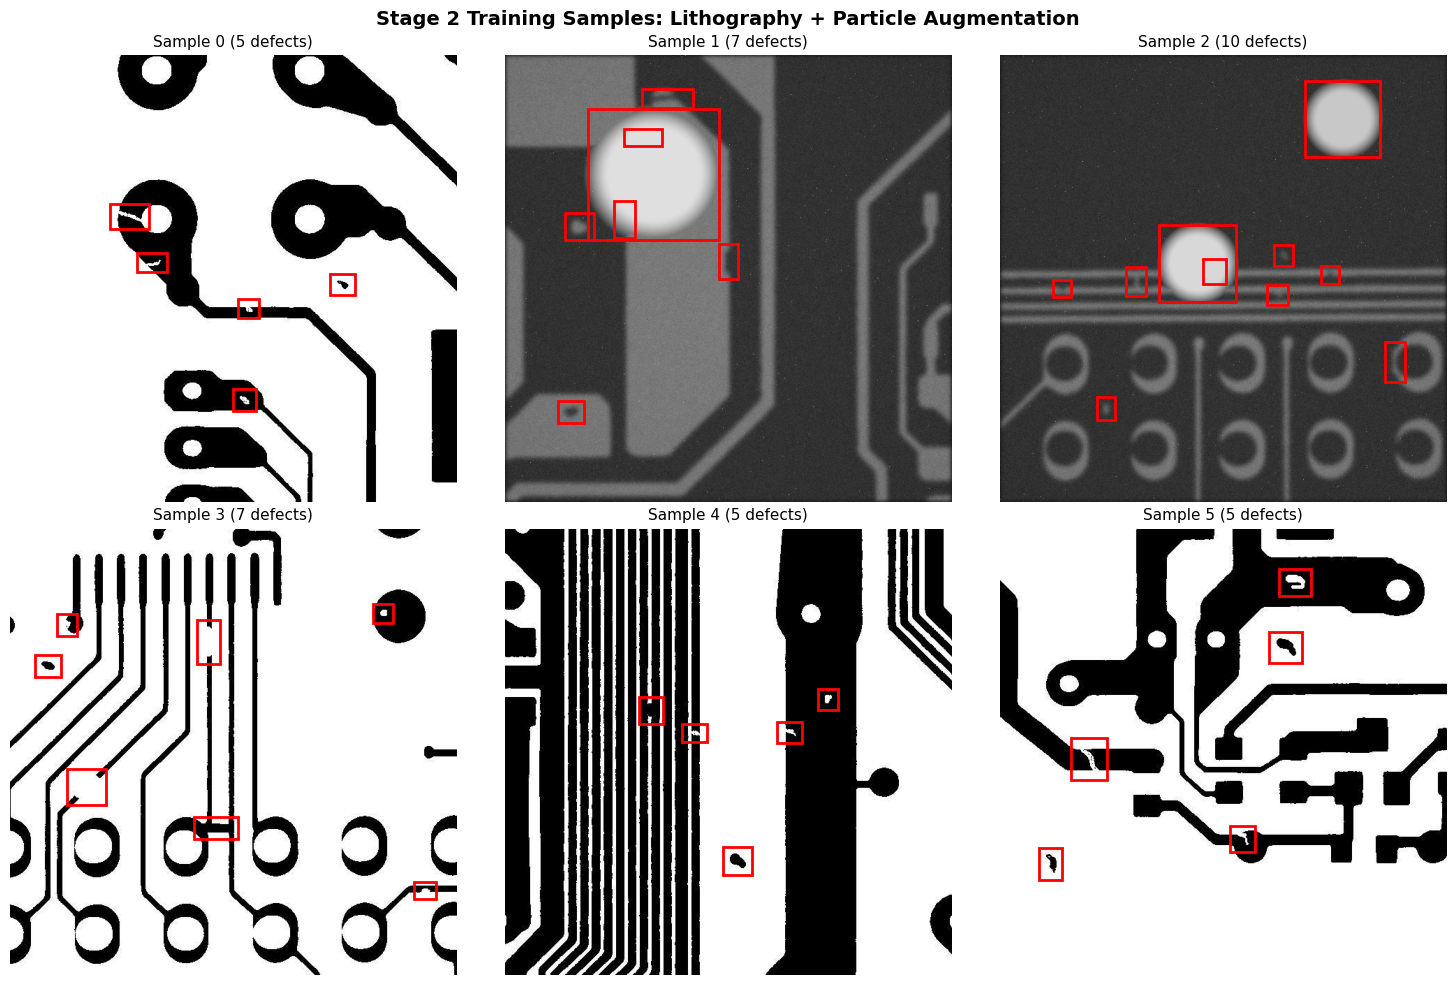

  [Checkpoint] Resuming from epoch 21 (loaded from models\defect_detector_stage2_checkpoint.pth)

[Stage 2] Fine-tuning from epoch 21 to 40 (20 epochs this run)...
  Total epochs after this run: 40

===== Epoch 21/40 (Stage 2: Lithography + Particles) =====


Train Epoch 21: 100%|██████████| 264/264 [02:36<00:00,  1.69it/s, loss=0.3312]



Validation | TP: 1740 FP: 508 FN: 519 | Precision: 0.774 Recall: 0.770

===== Epoch 22/40 (Stage 2: Lithography + Particles) =====


Train Epoch 22: 100%|██████████| 264/264 [02:34<00:00,  1.71it/s, loss=0.3157]



Validation | TP: 1738 FP: 481 FN: 507 | Precision: 0.783 Recall: 0.774

===== Epoch 23/40 (Stage 2: Lithography + Particles) =====


...

Validation | TP: 1734 FP: 485 FN: 502 | Precision: 0.781 Recall: 0.775

===== Epoch 39/40 (Stage 2: Lithography + Particles) =====


Train Epoch 39: 100%|██████████| 264/264 [02:36<00:00,  1.69it/s, loss=0.3199]



Validation | TP: 1755 FP: 485 FN: 492 | Precision: 0.783 Recall: 0.781

===== Epoch 40/40 (Stage 2: Lithography + Particles) =====


Train Epoch 40: 100%|██████████| 264/264 [02:41<00:00,  1.63it/s, loss=0.3376]



Validation | TP: 1713 FP: 499 FN: 559 | Precision: 0.774 Recall: 0.754
  [Checkpoint] Saved at epoch 40 to models\defect_detector_stage2_checkpoint.pth
  [Checkpoint] Saved at epoch 40 to models\defect_detector_stage2_checkpoint.pth

Saved Stage 2 fine-tuned model to: models\defect_detector_stage2_litho_finetuned.pth

Saved Stage 2 fine-tuned model to: models\defect_detector_stage2_litho_finetuned.pth


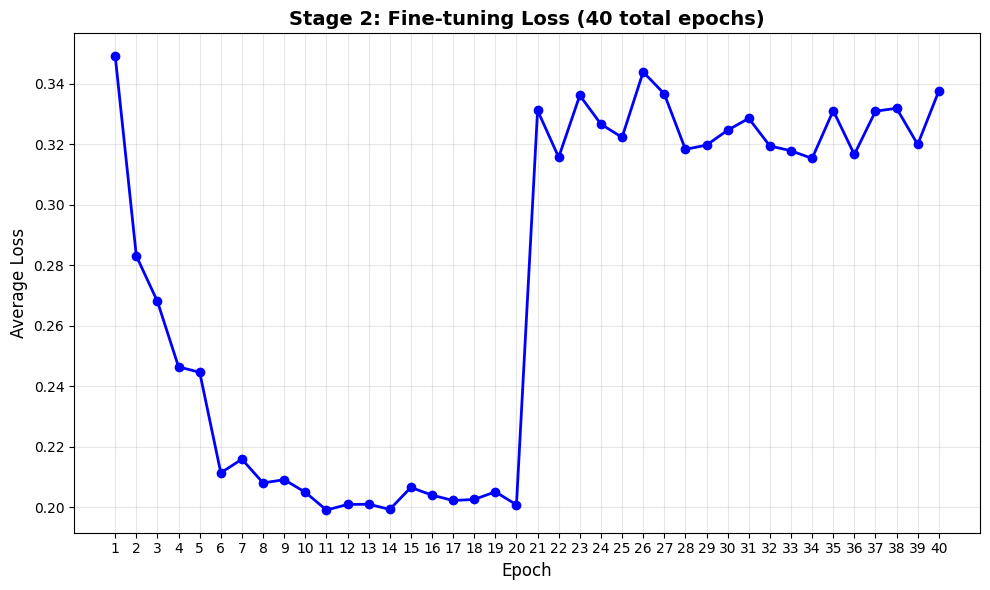

  Loss curve saved to models/stage2_finetune_loss_curve.png


In [6]:
# Stage 2: Fine-tune with lithography-based augmentation and particle injection

# Rebuild training dataset with lithography augmentation + particle injection
train_dataset_litho = PCBDefectsCocoDataset(
    root_dir=DATA_ROOT,
    ann_path=TRAIN_JSON,
    transforms=get_train_transforms_with_litho(p=0.5, inject_particles=True),
    one_class=USE_ONE_CLASS,
)

# Validation dataset WITH particle injection for Stage 2
valid_dataset_litho = PCBDefectsCocoDataset(
    root_dir=DATA_ROOT,
    ann_path=VALID_JSON,
    transforms=get_train_transforms_with_litho(p=1.0, inject_particles=True),  # Always apply for validation
    one_class=USE_ONE_CLASS,
)

train_loader_litho = DataLoader(
    train_dataset_litho,
    batch_size=4,
    shuffle=True,
    num_workers=0,  # Windows compatibility: 0 avoids multiprocessing hang
    collate_fn=collate_fn,
)

valid_loader_litho = DataLoader(
    valid_dataset_litho,
    batch_size=4,
    shuffle=False,
    num_workers=0,  # Windows compatibility: 0 avoids multiprocessing hang
    collate_fn=collate_fn,
)

print(f"Stage 2 Training set: {len(train_dataset_litho)} images (with lithography + particles)")
print(f"Stage 2 Validation set: {len(valid_dataset_litho)} images (with lithography + particles)")

# Visualize some augmented samples with particles
print("\nVisualizing Stage 2 augmented samples with synthetic particles...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    img, target = train_dataset_litho[i]
    img_np = img.permute(1, 2, 0).numpy()
    
    ax = axes[i]
    ax.imshow(img_np)
    boxes = target["boxes"].numpy()
    ax.set_title(f"Sample {i} ({len(boxes)} defects)", fontsize=11)
    ax.axis("off")
    
    for (x1, y1, x2, y2) in boxes:
        w, h = x2 - x1, y2 - y1
        rect = plt.Rectangle((x1, y1), w, h, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)

plt.suptitle("Stage 2 Training Samples: Lithography + Particle Augmentation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Load baseline weights from Stage 1 and fine-tune
finetune_model = create_defect_detector(one_class=USE_ONE_CLASS)
finetune_model.to(DEVICE)

# Try loading from Stage 2 checkpoint first, then fall back to Stage 1 baseline
finetune_checkpoint_path = os.path.join("models", "defect_detector_stage2_checkpoint.pth")
finetuned_path = os.path.join("models", "defect_detector_stage2_litho_finetuned.pth")

params_ft = [p for p in finetune_model.parameters() if p.requires_grad]
optimizer_ft = torch.optim.SGD(params_ft, lr=0.002, momentum=0.9, weight_decay=0.0005)
scheduler_ft = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

# Try to resume from Stage 2 checkpoint
if os.path.isfile(finetune_checkpoint_path):
    start_epoch_ft, stage2_losses = load_checkpoint(finetune_checkpoint_path, finetune_model, optimizer_ft, scheduler_ft, DEVICE)
elif os.path.isfile(baseline_path):
    state_dict = torch.load(baseline_path, map_location=DEVICE)
    finetune_model.load_state_dict(state_dict)
    print("Loaded Stage 1 baseline weights for fine-tuning.")
    start_epoch_ft = 1
    stage2_losses = []
else:
    print("WARNING: Stage 1 baseline weights not found; fine-tuning will start from ImageNet-pretrained weights.")
    start_epoch_ft = 1
    stage2_losses = []

# CONFIGURATION: Number of epochs to train each time you run this cell
epochs_per_run_ft = 20  # Change this to train more/fewer epochs per run
checkpoint_frequency_ft = 5

# Calculate end epoch: start from where we left off and train for epochs_per_run_ft more
end_epoch_ft = start_epoch_ft + epochs_per_run_ft - 1
print(f"\n[Stage 2] Fine-tuning from epoch {start_epoch_ft} to {end_epoch_ft} ({epochs_per_run_ft} epochs this run)...")
print(f"  Total epochs after this run: {end_epoch_ft}")

for epoch in range(start_epoch_ft, end_epoch_ft + 1):
    print(f"\n===== Epoch {epoch}/{end_epoch_ft} (Stage 2: Lithography + Particles) =====")
    epoch_loss = train_one_epoch(finetune_model, optimizer_ft, train_loader_litho, DEVICE, epoch)
    stage2_losses.append(epoch_loss)
    metrics = evaluate_one_epoch(finetune_model, valid_loader_litho, DEVICE)  # Validate with particles
    scheduler_ft.step()
    
    # Save checkpoint every 5 epochs
    if epoch % checkpoint_frequency_ft == 0:
        save_checkpoint(finetune_checkpoint_path, epoch, finetune_model, optimizer_ft, scheduler_ft, stage2_losses)

# Save fine-tuned model (just weights for inference)
torch.save(finetune_model.state_dict(), finetuned_path)
print(f"\nSaved Stage 2 fine-tuned model to: {finetuned_path}")

# Plot Stage 2 training loss
plot_training_loss(stage2_losses, f"Stage 2: Fine-tuning Loss ({len(stage2_losses)} total epochs)", "stage2_finetune")